<a href="https://colab.research.google.com/github/engineerchacon/Procesamiento-de-Lenguaje-Natural/blob/main/Ejercicios_de_representaci%C3%B3n_de_texto_(embeddings)_Armando_Chac%C3%B3n_Terrazas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Ejercicios de representación de texto (embeddings)-Armando Chacón Terrazas**

# Visualización semántica de palabras utilizando embeddings y t-SNE

Explorar la representación semántica de palabras e identifica los diferentes dominios temáticos contenidos en el conjunto de datos proporcionado mediante la visualización 2D de embeddings de palabras. Realiza y define las actividades de preprocesamiento del texto (si lo crees necesario) para que fácilmente puedas identificar en la visualización lo siguiente:
1.	¿Cuántos dominios o grupos de datos puedes identificar visualmente en la gráfica?
2.	¿Cuáles son esos dominios?

Instrucciones adicionales:
•	Genera la gráfica 2D de los embeddings de palabras utilizando t-SNE.
•	Visualiza en la gráfica las palabras de cada uno de los puntos.
•	De manera manual, encierra aproximadamente con óvalos los grupos o dominios que hayas identificado.
•	Incluye la gráfica final y tus observaciones en el documento de entrega.


1. INSTALACIÓN E IMPORTACIÓN DE HERRAMIENTAS (LIBRERÍAS)

In [1]:
# Esta línea le dice a Colab que instale la herramienta gensim
!pip install gensim
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from gensim.models import Word2Vec
import nltk
from nltk.corpus import stopwords
import re

# Descargamos las "palabras vacías" (stopwords)
nltk.download('stopwords')
nltk.download('punkt')
stop_words = set(stopwords.words('spanish'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


2. CONECTAR CON GOOGLE DRIVE Y CARGAR LOS DATOS

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Ruta exacta del archivo
ruta_archivo = '/content/drive/MyDrive/UACJ/Procesamiento de lenguaje natural/Ejercicios de Representación de textos - Embeddings.csv'

# Leemos el archivo CSV.
df = pd.read_csv(ruta_archivo)
columna_texto = 'frase'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


3. PREPROCESAMIENTO DEL TEXTO

In [3]:
# Definimos una función que limpia el texto para que el modelo no se confunda.
def limpiar_texto(texto):
    if type(texto) != str:
        return []
    texto = texto.lower() # Convertimos todo a minúsculas (para que "Hola" y "hola" sean lo mismo).
    texto = re.sub(r'[^\w\s]', '', texto) # Quitamos signos de puntuación (!, ?, ., ,).
    palabras = texto.split() # Separamos las frases en palabras individuales.
    # Filtramos las palabras vacías y números
    palabras_limpias = [p for p in palabras if p not in stop_words and not p.isdigit()]
    return palabras_limpias

# Aplicamos la limpieza a toda la columna de nuestro archivo.
df['texto_limpio'] = df[columna_texto].apply(limpiar_texto)

4. ENTRENAMIENTO DEL MODELO DE EMBEDDINGS (Word2Vec)

In [4]:
# Extraemos todas las listas de palabras limpias para entrenar el modelo.
oraciones = df['texto_limpio'].tolist()

# Entrenamos nuestro propio modelo desde cero (como se mencionó en la clase).
# vector_size=100 significa que cada palabra se representará con una lista de 100 números.
modelo_w2v = Word2Vec(sentences=oraciones, vector_size=100, window=5, min_count=1, workers=4)

# Obtenemos la lista de todas las palabras únicas que el modelo aprendió.
palabras = list(modelo_w2v.wv.index_to_key)

# Extraemos los vectores de cada palabra. X_w2v será una matriz con puros números.
X_w2v = modelo_w2v.wv[palabras]

5. REDUCCIÓN DE DIMENSIONALIDAD CON t-SNE

In [5]:
# Como no podemos visualizar 100 dimensiones, usamos t-SNE para aplastarlas a 2D (ejes X y Y).
# Nota: Si se tiene muy pocas palabras, perplexity debe ser menor al número de palabras.
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(palabras)-1))
X_2d = tsne.fit_transform(X_w2v)

6. VISUALIZACIÓN EN 2D (Generación de la Gráfica)

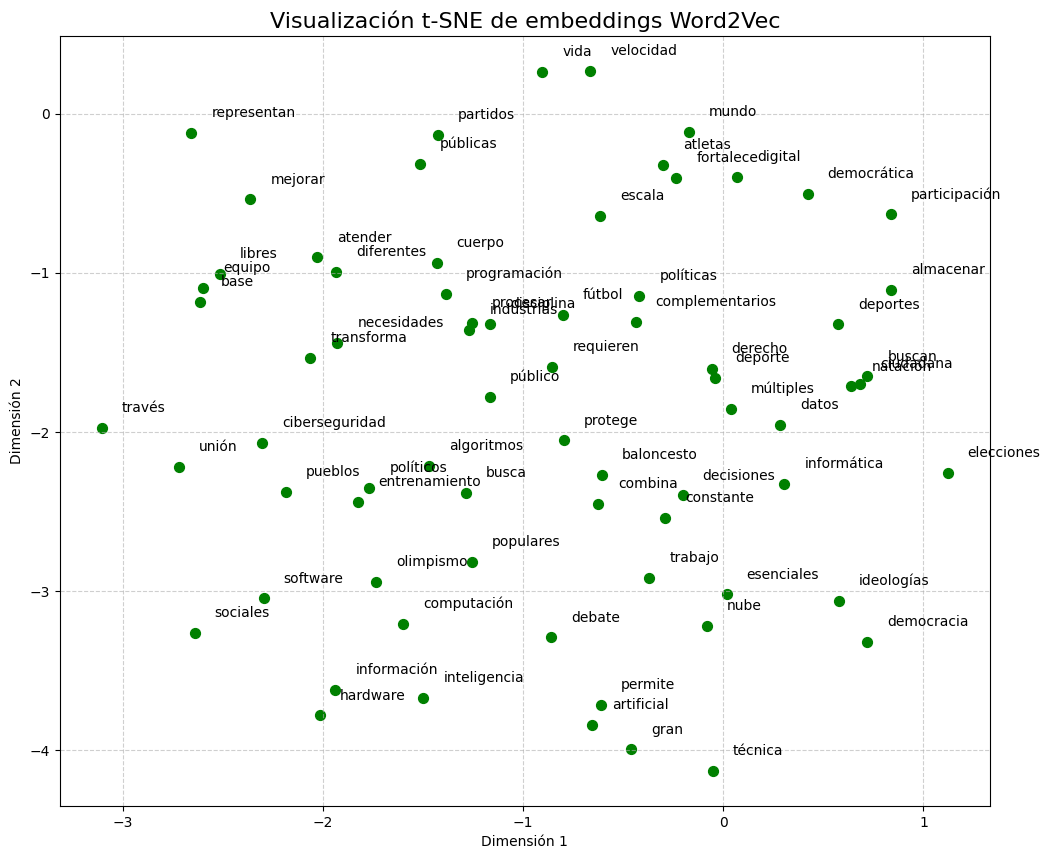

In [9]:
plt.figure(figsize=(12, 10)) # Tamaño de la gráfica (ancho, alto)

# Recorremos cada palabra y sus coordenadas (X, Y) para dibujarlas.
for i, palabra in enumerate(palabras):
    x, y = X_2d[i, 0], X_2d[i, 1]
    plt.scatter(x, y, c="green", s=50) # Dibuja el punto azul
    plt.text(x + 0.1, y + 0.1, palabra, fontsize=10) # Coloca el texto de la palabra junto al punto

plt.title("Visualización t-SNE de embeddings Word2Vec", fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6) # Agregamos una cuadrícula sutil de fondo
plt.xlabel("Dimensión 1")
plt.ylabel("Dimensión 2")
plt.show() # Mostramos la gráfica final